# Session 28: Transfer Learning with PyTorch
### Duration: ~2.5-3 Hours

---

## Session Goal
In Session 27, we trained a CNN from scratch on small digit images.

In this session, we learn a very common real-world deep learning workflow:

> Use a model that was already trained on a large dataset, then adapt it to our smaller task.

This is called **transfer learning**.

## What Students Will Learn
- What transfer learning means
- Why pretrained models are useful
- What ImageNet is
- What it means to freeze layers
- What it means to replace the classifier head
- The difference between feature extraction and fine-tuning
- How to use a pretrained CNN in PyTorch
- How to train only the final classifier layer
- How to evaluate the adapted model

## Dataset
We will use a small subset of the famous **CIFAR-10** dataset.

The full CIFAR-10 dataset has 10 image classes. For this beginner transfer-learning session, we use only two classes:

```text
cat vs dog
```

This keeps the lesson simple and fast.

---
## 1. What Is Transfer Learning?

Transfer learning means reusing knowledge from one task and applying it to another task.

Example:

```text
A pretrained CNN has learned general image patterns from millions of images.
We reuse those learned patterns for our own smaller image task.
```

A pretrained image model may already know useful visual features such as:

```text
edges -> corners -> textures -> shapes -> object parts
```

So instead of training everything from zero, we start from a model that already understands many image patterns.

---
## 2. Why Transfer Learning Is Useful

Training a deep CNN from scratch can require:

- A large dataset
- A lot of time
- Powerful hardware
- Careful tuning

Transfer learning helps when:

- Our dataset is small
- We do not have a GPU
- We want faster training
- We want better accuracy with less data

Real-world examples:

```text
Plant disease classification
Medical image classification
Product image classification
Defect detection in factories
Animal classification
```

---
## 3. Feature Extraction vs Fine-Tuning

There are two common transfer learning approaches.

### Approach 1: Feature Extraction

Freeze the pretrained model and train only a new classifier.

```text
Pretrained CNN backbone: frozen
New classifier head: trainable
```

This is easier and safer for beginners.

### Approach 2: Fine-Tuning

Unfreeze some pretrained layers and train them slightly on the new dataset.

```text
Pretrained CNN backbone: partly trainable
New classifier head: trainable
```

Fine-tuning can improve performance, but it is more sensitive to learning rate and overfitting.

In this session, we use **feature extraction**.

---
## 4. The Transfer Learning Workflow

A typical workflow looks like this:

```text
1. Load a pretrained model
2. Freeze the pretrained feature extractor
3. Replace the final classifier layer
4. Train only the new classifier
5. Evaluate on test data
6. Optionally unfreeze some layers and fine-tune
```

Today we stop at step 5.

That is enough for a first transfer learning class.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import MobileNet_V2_Weights

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = Path('data')
OUTPUT_DIR = Path('session28_artifacts')
OUTPUT_DIR.mkdir(exist_ok=True)

print('PyTorch version:', torch.__version__)
print('Torchvision version:', torchvision.__version__)
print('Using device:', DEVICE)

PyTorch version: 2.12.1+cpu
Torchvision version: 0.27.1+cpu
Using device: cpu


---
## 5. Load CIFAR-10

CIFAR-10 is a famous image dataset with 10 classes:

```text
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
```

Images are small:

```text
32 x 32 color images
```

For this session, we use only:

```text
cat and dog
```

The pretrained MobileNetV2 model expects image normalization similar to ImageNet, so we resize and normalize the images.

In [2]:
image_size = 96

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_full = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
test_full = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)

print('Full training images:', len(train_full))
print('Full test images:', len(test_full))
print('Classes:', train_full.classes)

Full training images: 50000
Full test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
## 6. Create a Small Cat-vs-Dog Subset

To keep training quick in class, we use a small balanced subset.

Original CIFAR-10 labels:

```text
cat = 3
dog = 5
```

We remap them to:

```text
cat = 0
dog = 1
```

In [3]:
CLASS_NAMES = ['cat', 'dog']
ORIGINAL_CLASS_IDS = {3: 0, 5: 1}


def make_balanced_subset(dataset, original_class_ids, samples_per_class):
    targets = np.array(dataset.targets)
    selected_indices = []

    for original_label in original_class_ids:
        class_indices = np.where(targets == original_label)[0]
        rng = np.random.default_rng(RANDOM_STATE + original_label)
        chosen = rng.choice(class_indices, size=samples_per_class, replace=False)
        selected_indices.extend(chosen.tolist())

    rng = np.random.default_rng(RANDOM_STATE)
    rng.shuffle(selected_indices)
    return selected_indices

train_indices = make_balanced_subset(train_full, ORIGINAL_CLASS_IDS, samples_per_class=200)
test_indices = make_balanced_subset(test_full, ORIGINAL_CLASS_IDS, samples_per_class=80)

train_subset = Subset(train_full, train_indices)
test_subset = Subset(test_full, test_indices)

print('Training subset size:', len(train_subset))
print('Test subset size:', len(test_subset))

Training subset size: 400
Test subset size: 160


In [4]:
class BinaryCIFAR10Subset(torch.utils.data.Dataset):
    def __init__(self, subset, original_class_ids):
        self.subset = subset
        self.original_class_ids = original_class_ids

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, original_label = self.subset[index]
        binary_label = self.original_class_ids[original_label]
        return image, binary_label

train_dataset = BinaryCIFAR10Subset(train_subset, ORIGINAL_CLASS_IDS)
test_dataset = BinaryCIFAR10Subset(test_subset, ORIGINAL_CLASS_IDS)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print('Training batches:', len(train_loader))
print('Test batches:', len(test_loader))

Training batches: 13
Test batches: 3


---
## 7. Visualize Training Images

Because we normalized the images for the pretrained model, we need to undo normalization before displaying them.

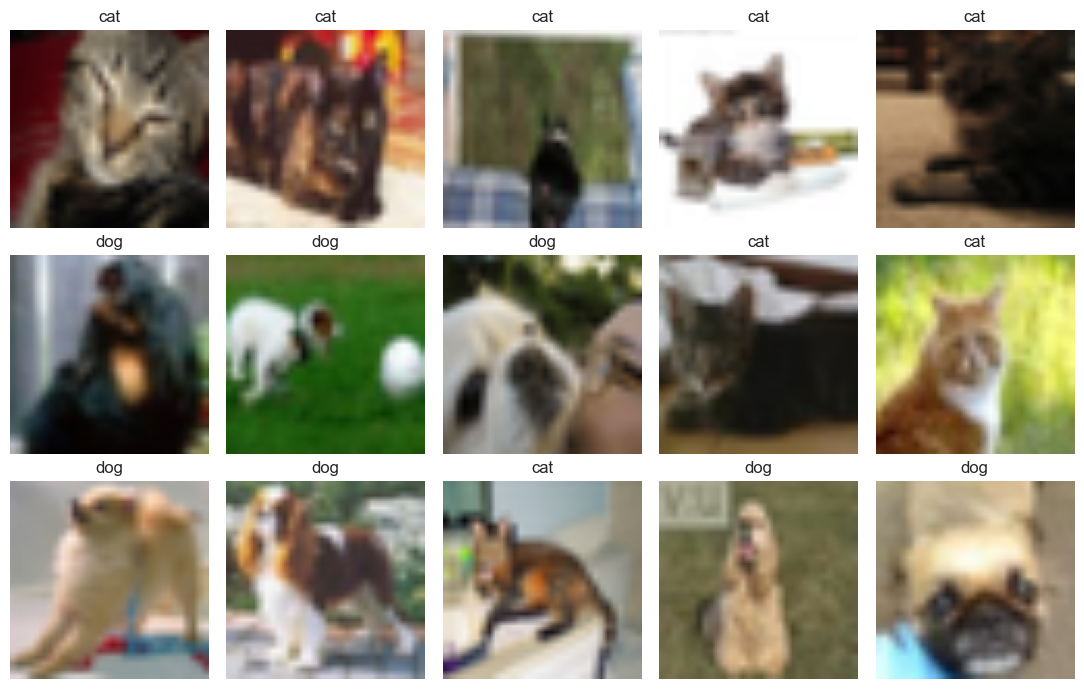

In [5]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def unnormalize(image_tensor):
    image = image_tensor.cpu() * std + mean
    image = image.clamp(0, 1)
    return image.permute(1, 2, 0).numpy()

batch_images, batch_labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 5, figsize=(11, 7))
axes = axes.ravel()

for ax, image, label in zip(axes, batch_images[:15], batch_labels[:15]):
    ax.imshow(unnormalize(image))
    ax.set_title(CLASS_NAMES[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 8. Load a Pretrained MobileNetV2

MobileNetV2 is a CNN architecture designed to be efficient.

We load a version pretrained on ImageNet.

ImageNet is a very large image dataset with many object categories.

Important idea:

```text
The model already learned useful image patterns from ImageNet.
```

We will reuse those patterns for cat-vs-dog classification.

In [6]:
weights = MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


---
## 9. Freeze the Pretrained Backbone

Freezing means:

```text
Do not update these weights during training.
```

We freeze the feature extractor because it already learned useful image features.

Then we replace the classifier head with a new layer for 2 classes.

In [7]:
for parameter in model.features.parameters():
    parameter.requires_grad = False

num_input_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_input_features, 2)
model = model.to(DEVICE)

trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_parameters = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print('New classifier:')
print(model.classifier)
print('\nTrainable parameters:', trainable_parameters)
print('Frozen parameters:', frozen_parameters)

New classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

Trainable parameters: 2562
Frozen parameters: 2223872


---
## 10. Loss Function and Optimizer

Because this is a 2-class classification task, we use:

```text
CrossEntropyLoss
```

The optimizer only updates parameters where:

```text
requires_grad = True
```

In our case, that is mainly the new classifier layer.

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

print('Loss function:', criterion)
print('Optimizer:', optimizer.__class__.__name__)

Loss function: CrossEntropyLoss()
Optimizer: Adam


---
## 11. Training and Evaluation Functions

The training loop is similar to Session 27.

The big difference is that most of the CNN is frozen.

In [9]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images_batch, labels_batch in data_loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images_batch)
        loss = criterion(outputs, labels_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images_batch.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels_batch).sum().item()
        total += labels_batch.size(0)

    return total_loss / total, correct / total


def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images_batch, labels_batch in data_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images_batch)
            loss = criterion(outputs, labels_batch)

            total_loss += loss.item() * images_batch.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels_batch).sum().item()
            total += labels_batch.size(0)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_predictions), np.array(all_labels)

---
## 12. Train Only the New Classifier

We train for a few epochs only.

Since the pretrained backbone is frozen, training is faster than training the whole CNN from scratch.

In [18]:
history = []
EPOCHS = 10

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, DEVICE)

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_accuracy': train_acc,
        'test_loss': test_loss,
        'test_accuracy': test_acc,
    })

    print(
        f'Epoch {epoch:02d} | '
        f'Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | '
        f'Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}'
    )

history_df = pd.DataFrame(history)
history_df

Epoch 01 | Train loss: 0.4208 | Train acc: 0.8375 | Test loss: 0.5401 | Test acc: 0.7312
Epoch 02 | Train loss: 0.3793 | Train acc: 0.8475 | Test loss: 0.5319 | Test acc: 0.7500
Epoch 03 | Train loss: 0.3641 | Train acc: 0.8625 | Test loss: 0.5261 | Test acc: 0.7562
Epoch 04 | Train loss: 0.3519 | Train acc: 0.8525 | Test loss: 0.5307 | Test acc: 0.7500
Epoch 05 | Train loss: 0.3449 | Train acc: 0.8800 | Test loss: 0.5319 | Test acc: 0.7312
Epoch 06 | Train loss: 0.3414 | Train acc: 0.8625 | Test loss: 0.5380 | Test acc: 0.7438
Epoch 07 | Train loss: 0.3466 | Train acc: 0.8650 | Test loss: 0.5422 | Test acc: 0.7250
Epoch 08 | Train loss: 0.3199 | Train acc: 0.8825 | Test loss: 0.5468 | Test acc: 0.7312
Epoch 09 | Train loss: 0.3045 | Train acc: 0.8950 | Test loss: 0.5347 | Test acc: 0.7438
Epoch 10 | Train loss: 0.3049 | Train acc: 0.8800 | Test loss: 0.5284 | Test acc: 0.7438


,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,0.420785,0.8375,0.540109,0.73125
1,2,0.379323,0.8475,0.531943,0.75000
2,3,0.364094,0.8625,0.526092,0.75625
3,4,0.351913,0.8525,0.530744,0.75000
4,5,0.344878,0.8800,0.531872,0.73125
5,6,0.341430,0.8625,0.538038,0.74375
6,7,0.346600,0.8650,0.542162,0.72500
7,8,0.319863,0.8825,0.546762,0.73125
8,9,0.304512,0.8950,0.534747,0.74375
9,10,0.304865,0.8800,0.528359,0.74375


---
## 13. Plot Training History

We check whether loss is going down and accuracy is improving.

With small datasets, test accuracy may move up and down. That is normal.

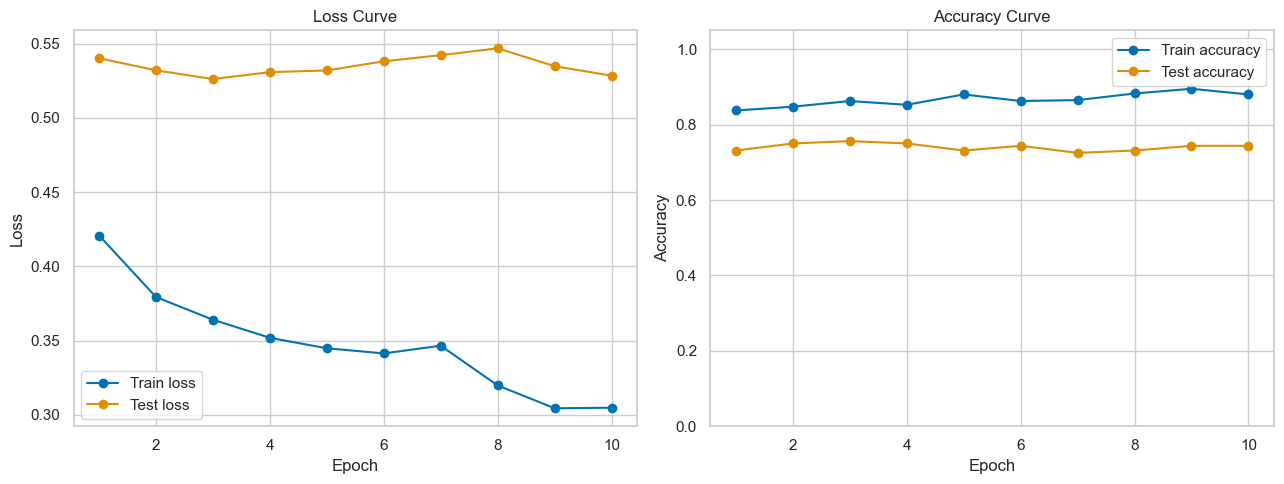

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train loss')
axes[0].plot(history_df['epoch'], history_df['test_loss'], marker='o', label='Test loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_accuracy'], marker='o', label='Train accuracy')
axes[1].plot(history_df['epoch'], history_df['test_accuracy'], marker='o', label='Test accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 14. Final Evaluation

Now we evaluate the transfer learning model on the test subset.

In [20]:
test_loss, test_accuracy, predictions, actuals = evaluate(model, test_loader, criterion, DEVICE)

print('Final test loss:', round(test_loss, 4))
print('Final test accuracy:', round(test_accuracy, 4))
print('\nClassification report:')
print(classification_report(actuals, predictions, target_names=CLASS_NAMES))

Final test loss: 0.5284
Final test accuracy: 0.7438

Classification report:
              precision    recall  f1-score   support

         cat       0.74      0.75      0.75        80
         dog       0.75      0.74      0.74        80

    accuracy                           0.74       160
   macro avg       0.74      0.74      0.74       160
weighted avg       0.74      0.74      0.74       160



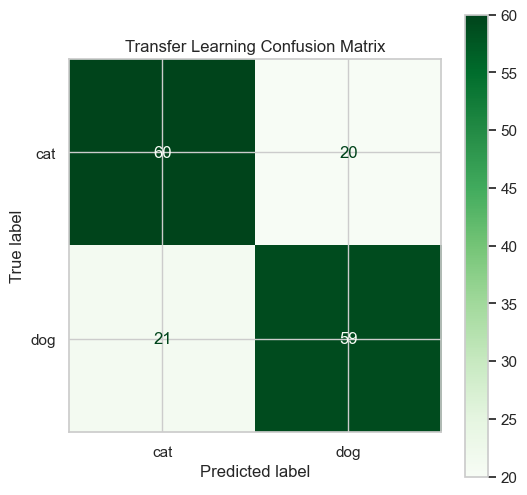

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    actuals,
    predictions,
    display_labels=CLASS_NAMES,
    cmap='Greens',
    ax=ax,
)
plt.title('Transfer Learning Confusion Matrix')
plt.show()

---
## 15. View Predictions

Green titles mean correct predictions.
Red titles mean incorrect predictions.

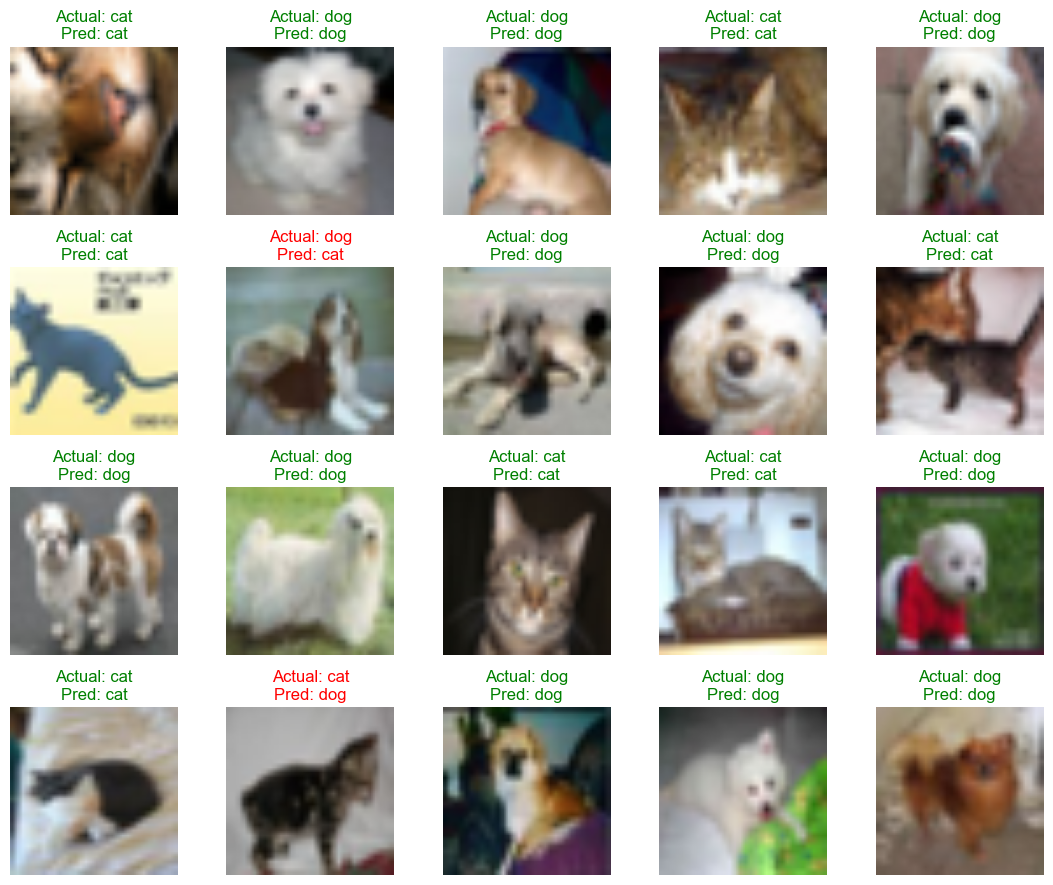

In [22]:
all_test_images = []
all_test_labels = []

for image_tensor, label in test_dataset:
    all_test_images.append(image_tensor)
    all_test_labels.append(label)

fig, axes = plt.subplots(4, 5, figsize=(11, 9))
axes = axes.ravel()

for ax, image_tensor, actual, pred in zip(axes, all_test_images[:20], actuals[:20], predictions[:20]):
    ax.imshow(unnormalize(image_tensor))
    color = 'green' if actual == pred else 'red'
    ax.set_title(f'Actual: {CLASS_NAMES[actual]}\nPred: {CLASS_NAMES[pred]}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 16. Prediction Probabilities

The model outputs logits.

We convert logits to probabilities using softmax.

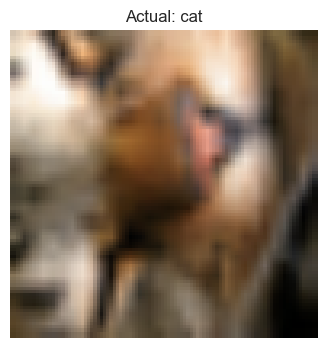

,class,probability
0,cat,0.8987
1,dog,0.1013


In [23]:
example_index = 0
example_image = all_test_images[example_index].unsqueeze(0).to(DEVICE)

model.eval()
with torch.no_grad():
    logits = model(example_image)
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]

prob_table = pd.DataFrame({
    'class': CLASS_NAMES,
    'probability': probabilities,
}).sort_values('probability', ascending=False)

plt.figure(figsize=(4, 4))
plt.imshow(unnormalize(all_test_images[example_index]))
plt.title(f'Actual: {CLASS_NAMES[all_test_labels[example_index]]}')
plt.axis('off')
plt.show()

prob_table.round(4)

---
## 17. What Would Fine-Tuning Look Like?

Today we used feature extraction:

```text
Frozen backbone + train new classifier
```

Fine-tuning would mean unfreezing some later layers:

```python
for parameter in model.features[-2:].parameters():
    parameter.requires_grad = True
```

Then we would train with a small learning rate, such as:

```python
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
```

Why small learning rate?

Because we do not want to destroy the useful pretrained knowledge too quickly.

We will not run fine-tuning today. For a first transfer learning session, feature extraction is enough.

---
## 18. When Should We Use Transfer Learning?

Transfer learning is useful when:

- You have a small or medium image dataset
- Your images are similar enough to the pretrained model's training data
- Training from scratch is too slow or needs too much data
- You want a strong baseline quickly

Transfer learning may be less useful when:

- Your data is very different from the pretrained dataset
- You have a huge labeled dataset of your own
- You need a very specialized architecture

For most beginner image projects, transfer learning is a very good next step.

In [24]:
transfer_learning_summary = pd.DataFrame({
    'term': [
        'Pretrained model',
        'Backbone',
        'Classifier head',
        'Freeze',
        'Feature extraction',
        'Fine-tuning',
    ],
    'meaning': [
        'A model already trained on a large dataset',
        'The feature-learning part of the model',
        'The final prediction layer for a task',
        'Stop weights from updating during training',
        'Use frozen pretrained features and train a new head',
        'Unfreeze some pretrained layers and train carefully',
    ],
})

transfer_learning_summary

,term,meaning
0,Pretrained model,A model already trained on a large dataset
1,Backbone,The feature-learning part of the model
2,Classifier head,The final prediction layer for a task
3,Freeze,Stop weights from updating during training
4,Feature extraction,Use frozen pretrained features and train a new...
5,Fine-tuning,Unfreeze some pretrained layers and train care...


---
## 19. Save the Model and Artifacts

For PyTorch transfer learning, we usually save the model weights with `torch.save`.

To reuse this model later, recreate the same MobileNetV2 structure and load the saved state dict.

In [25]:
model_path = OUTPUT_DIR / 'cifar10_cat_dog_transfer_learning_mobilenetv2.pt'
history_path = OUTPUT_DIR / 'transfer_learning_training_history.csv'
probability_path = OUTPUT_DIR / 'transfer_learning_example_probabilities.csv'
summary_path = OUTPUT_DIR / 'transfer_learning_terms.csv'

save_package = {
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'image_size': image_size,
    'architecture': 'mobilenet_v2',
}

torch.save(save_package, model_path)
history_df.to_csv(history_path, index=False)
prob_table.to_csv(probability_path, index=False)
transfer_learning_summary.to_csv(summary_path, index=False)

print('Saved model package:', model_path)
print('Saved training history:', history_path)
print('Saved prediction probabilities:', probability_path)
print('Saved summary terms:', summary_path)

Saved model package: session28_artifacts\cifar10_cat_dog_transfer_learning_mobilenetv2.pt
Saved training history: session28_artifacts\transfer_learning_training_history.csv
Saved prediction probabilities: session28_artifacts\transfer_learning_example_probabilities.csv
Saved summary terms: session28_artifacts\transfer_learning_terms.csv


---
## 20. Class Discussion Questions

Use these questions during class:

1. What does transfer learning mean?
2. Why is training a CNN from scratch difficult?
3. What is a pretrained model?
4. What is ImageNet?
5. What does it mean to freeze layers?
6. Why do we replace the classifier head?
7. What is the difference between feature extraction and fine-tuning?
8. Why should fine-tuning use a small learning rate?
9. When is transfer learning useful?
10. When might transfer learning not help much?

---

## Final Summary

Transfer learning lets us reuse knowledge from a model trained on a large dataset.

The core workflow is:

```text
Load pretrained model -> freeze backbone -> replace classifier -> train on new task
```

Today we used:

```text
Pretrained MobileNetV2 -> cat-vs-dog classifier on CIFAR-10
```

Key terms:

```text
pretrained model
backbone
classifier head
freeze
feature extraction
fine-tuning
```

Most important takeaway:

> Transfer learning is one of the most practical deep learning techniques because it helps us build useful models with less data and less training time.

Next recommended session:

```text
Session 29: Custom Image Classifier Capstone Project
```